# Pipeline A


## Phase 1: Data Cleaning and Preprocessing 

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import MinMaxScaler


print("--- PHASE 1: DATA CLEANING (COSMETIC RETAIL) ---")

# 1. Load cosmetics Dataset
df = pd.read_excel('cosmetic_data.xlsx', engine='openpyxl')

# Strip hidden spaces from all column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.upper()

# Handling missing person_IDs

df_retail = df.dropna(subset=['PERSON_ID'])

# Filter out negative sales
df = df[df['VALUE_AT_SELL'] > 0]

# Standardize Dates and STRICTLY sort chronologically
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'], format='%d/%b/%y')
df = df.sort_values(by='TRANSACTION_DATE').reset_index(drop=True)

print(f"Dataset cleaned. Remaining records: {len(df):,}")


print("\n--- PHASE 2: TIME-WINDOW SPLITTING (PREPARING THE CASCADE) ---")

def split_into_cycles(df, date_column='TRANSACTION_DATE', cycle_0_months=2):
    """Slices the cosmetic dataset into a 2-month baseline and monthly dynamic batches."""
    df['YearMonth'] = df[date_column].dt.to_period('M')
    unique_months = sorted(df['YearMonth'].unique())
    
    baseline_months = unique_months[:cycle_0_months]
    system_cycles = {}
    
    # Slice Cycle 0 (Baseline)
    cycle_0_df = df[df['YearMonth'].isin(baseline_months)].copy()
    cycle_0_df = cycle_0_df.drop(columns=['YearMonth'])
    system_cycles['Cycle_0'] = cycle_0_df
    
    # Slice Cycles 1-n (Dynamic Loop)
    remaining_months = unique_months[cycle_0_months:]
    cycle_num = 1
    for period in remaining_months:
        monthly_batch = df[df['YearMonth'] == period].copy()
        monthly_batch = monthly_batch.drop(columns=['YearMonth'])
        system_cycles[f'Cycle_{cycle_num}'] = monthly_batch
        cycle_num += 1
        
    return system_cycles

# Run the slicer (Using 2 months for the Cosmetic baseline)
all_cycles = split_into_cycles(df, cycle_0_months=2)

# 1. Verify Date Boundaries and Raw Transaction Counts
print("1. Transaction-Level Slicing (Checking Date Boundaries):")
for cycle_name, df_cycle in all_cycles.items():
    min_date = df_cycle['TRANSACTION_DATE'].min().strftime('%Y-%m-%d')
    max_date = df_cycle['TRANSACTION_DATE'].max().strftime('%Y-%m-%d')
    num_transactions = len(df_cycle)
    print(f"  {cycle_name}: {num_transactions:>7,} transactions | Start: {min_date} | End: {max_date}")



--- PHASE 1: DATA CLEANING (COSMETIC RETAIL) ---
Dataset cleaned. Remaining records: 199,768

--- PHASE 2: TIME-WINDOW SPLITTING (PREPARING THE CASCADE) ---
1. Transaction-Level Slicing (Checking Date Boundaries):
  Cycle_0:  28,285 transactions | Start: 2024-01-01 | End: 2024-02-29
  Cycle_1:  16,953 transactions | Start: 2024-03-01 | End: 2024-03-31
  Cycle_2:  17,844 transactions | Start: 2024-04-01 | End: 2024-04-30
  Cycle_3:  19,846 transactions | Start: 2024-05-01 | End: 2024-05-31
  Cycle_4:  15,665 transactions | Start: 2024-06-01 | End: 2024-06-30
  Cycle_5:  17,480 transactions | Start: 2024-07-01 | End: 2024-07-31
  Cycle_6:  18,599 transactions | Start: 2024-08-01 | End: 2024-08-31
  Cycle_7:  14,445 transactions | Start: 2024-09-01 | End: 2024-09-30
  Cycle_8:  16,708 transactions | Start: 2024-10-01 | End: 2024-10-31
  Cycle_9:  14,878 transactions | Start: 2024-11-01 | End: 2024-11-30
  Cycle_10:  19,065 transactions | Start: 2024-12-01 | End: 2024-12-31


### Cascaded RFM Implementation

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import MinMaxScaler


print("\n--- PHASE 3: CASCADED RFM  ---")

def assign_recency_bin(days):
    """Isolates Recency into strict categorical risk brackets."""
    if days <= 30: return 1   # 'Best' (Active)
    elif days <= 60: return 2 # 'Loyal' (Recent)
    elif days <= 90: return 3 # 'Almost Lost' (Slipping)
    else: return 4            # 'Lost' (Inactive)

def apply_advanced_cascaded_rfm(cycles_dict):
    
    rfm_profiles = {}
    scaler = MinMaxScaler() # Initialize the scaler for distance math
    
    for cycle_name, df_cycle in cycles_dict.items():
        
        # --- SAFETY NET 1: Drop any duplicate columns inherited from raw Excel data ---
        df_cycle = df_cycle.loc[:, ~df_cycle.columns.duplicated()].copy()
        
        # Snapshot date: 1 day after the last transaction in THIS specific cycle
        snapshot_date = df_cycle['TRANSACTION_DATE'].max() + dt.timedelta(days=1)
        
        # 1. BASE CALCULATION (Using your excellent Named Aggregation!)
        rfm = df_cycle.groupby('PERSON_ID').agg(
            Recency=('TRANSACTION_DATE', lambda x: (snapshot_date - x.max()).days),
            Frequency=('TRANSACTION_DATE', 'nunique'),
            Monetary=('VALUE_AT_SELL', 'sum')
        ).reset_index()
        
        # --- SAFETY NET 2: Ensure no duplicates accidentally survived the groupby ---
        rfm = rfm.loc[:, ~rfm.columns.duplicated()].copy()
        
        # 2. RECENCY ISOLATION
        rfm['Recency_Bucket'] = rfm['Recency'].apply(assign_recency_bin)
        
        # 3. STRUCTURAL PAIRING (Log Transformation)
        rfm['Log_R'] = np.log1p(rfm['Recency'])
        rfm['Log_F'] = np.log1p(rfm['Frequency'])
        rfm['Log_M'] = np.log1p(rfm['Monetary'])
        
        # Interaction features for the "Structural Pairs"
        rfm['RF_Score'] = rfm['Log_R'] * rfm['Log_F']
        rfm['RM_Score'] = rfm['Log_R'] * rfm['Log_M']
        rfm['FM_Score'] = rfm['Log_F'] * rfm['Log_M']
        
        # 4. MATHEMATICAL SCALING
        features_to_scale = ['Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score']
        
        # Create scaled versions of these columns (This will now run perfectly!)
        scaled_array = scaler.fit_transform(rfm[features_to_scale])
        scaled_df = pd.DataFrame(scaled_array, columns=[f"Scaled_{col}" for col in features_to_scale])
        
        # Join the scaled features back to the main RFM table
        rfm_final = pd.concat([rfm, scaled_df], axis=1)
        
        # Save to dictionary
        rfm_profiles[cycle_name] = rfm_final
        
    return rfm_profiles

# Execute the Advanced Cascaded RFM
rfm_cycles = apply_advanced_cascaded_rfm(all_cycles)

# Verify Cycle 0
print(f"Total Unique Customers in Cycle 0: {len(rfm_cycles['Cycle_0']):,}")
print("\nSample Cascaded RFM Features (Cycle 0):")
print(rfm_cycles['Cycle_0'][['PERSON_ID', 'Recency_Bucket', 'Scaled_RF_Score', 'Scaled_RM_Score', 'Scaled_FM_Score']].head())


--- PHASE 3: CASCADED RFM (SOBANTU & ISAFIADE, 2024) ---
Total Unique Customers in Cycle 0: 13,780

Sample Cascaded RFM Features (Cycle 0):
   PERSON_ID  Recency_Bucket  Scaled_RF_Score  Scaled_RM_Score  \
0     2912.0               2         0.409452         0.582423   
1     4104.0               2         0.349685         0.565980   
2    10968.0               1         0.327627         0.397039   
3    12314.0               1         0.300631         0.468839   
4    16742.0               2         0.409452         0.549531   

   Scaled_FM_Score  
0         0.086849  
1         0.104819  
2         0.064452  
3         0.097186  
4         0.078710  


--- VISUALIZING LOG TRANSFORMATION (PIPELINE B) ---


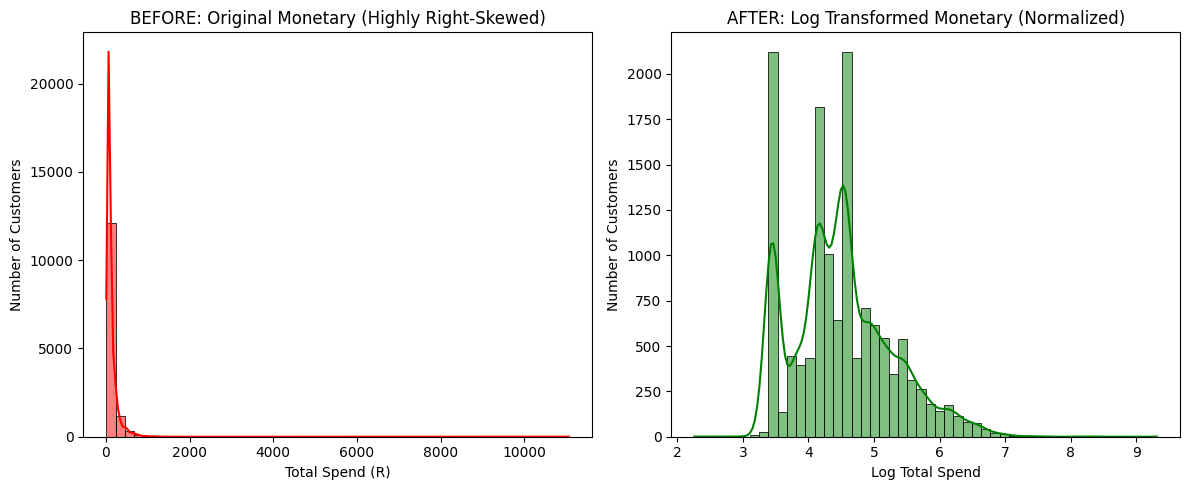

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALIZING LOG TRANSFORMATION (PIPELINE B) ---")

# We will look at the Baseline Cycle (Cycle 0) for the plot
baseline_rfm = rfm_cycles['Cycle_0']

# Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: BEFORE Log Transformation (Original Data)
sns.histplot(baseline_rfm['Monetary'], bins=50, ax=axes[0], color='red', kde=True)
axes[0].set_title('BEFORE: Original Monetary (Highly Right-Skewed)')
axes[0].set_xlabel('Total Spend (R)')
axes[0].set_ylabel('Number of Customers')

# Plot 2: AFTER Log Transformation
sns.histplot(baseline_rfm['Log_M'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title('AFTER: Log Transformed Monetary (Normalized)')
axes[1].set_xlabel('Log Total Spend')
axes[1].set_ylabel('Number of Customers')

# Show the graphs
plt.tight_layout()
plt.show()

--- VISUALIZING THE FULL PREPROCESSING PIPELINE (PIPELINE A: COSMETICS) ---


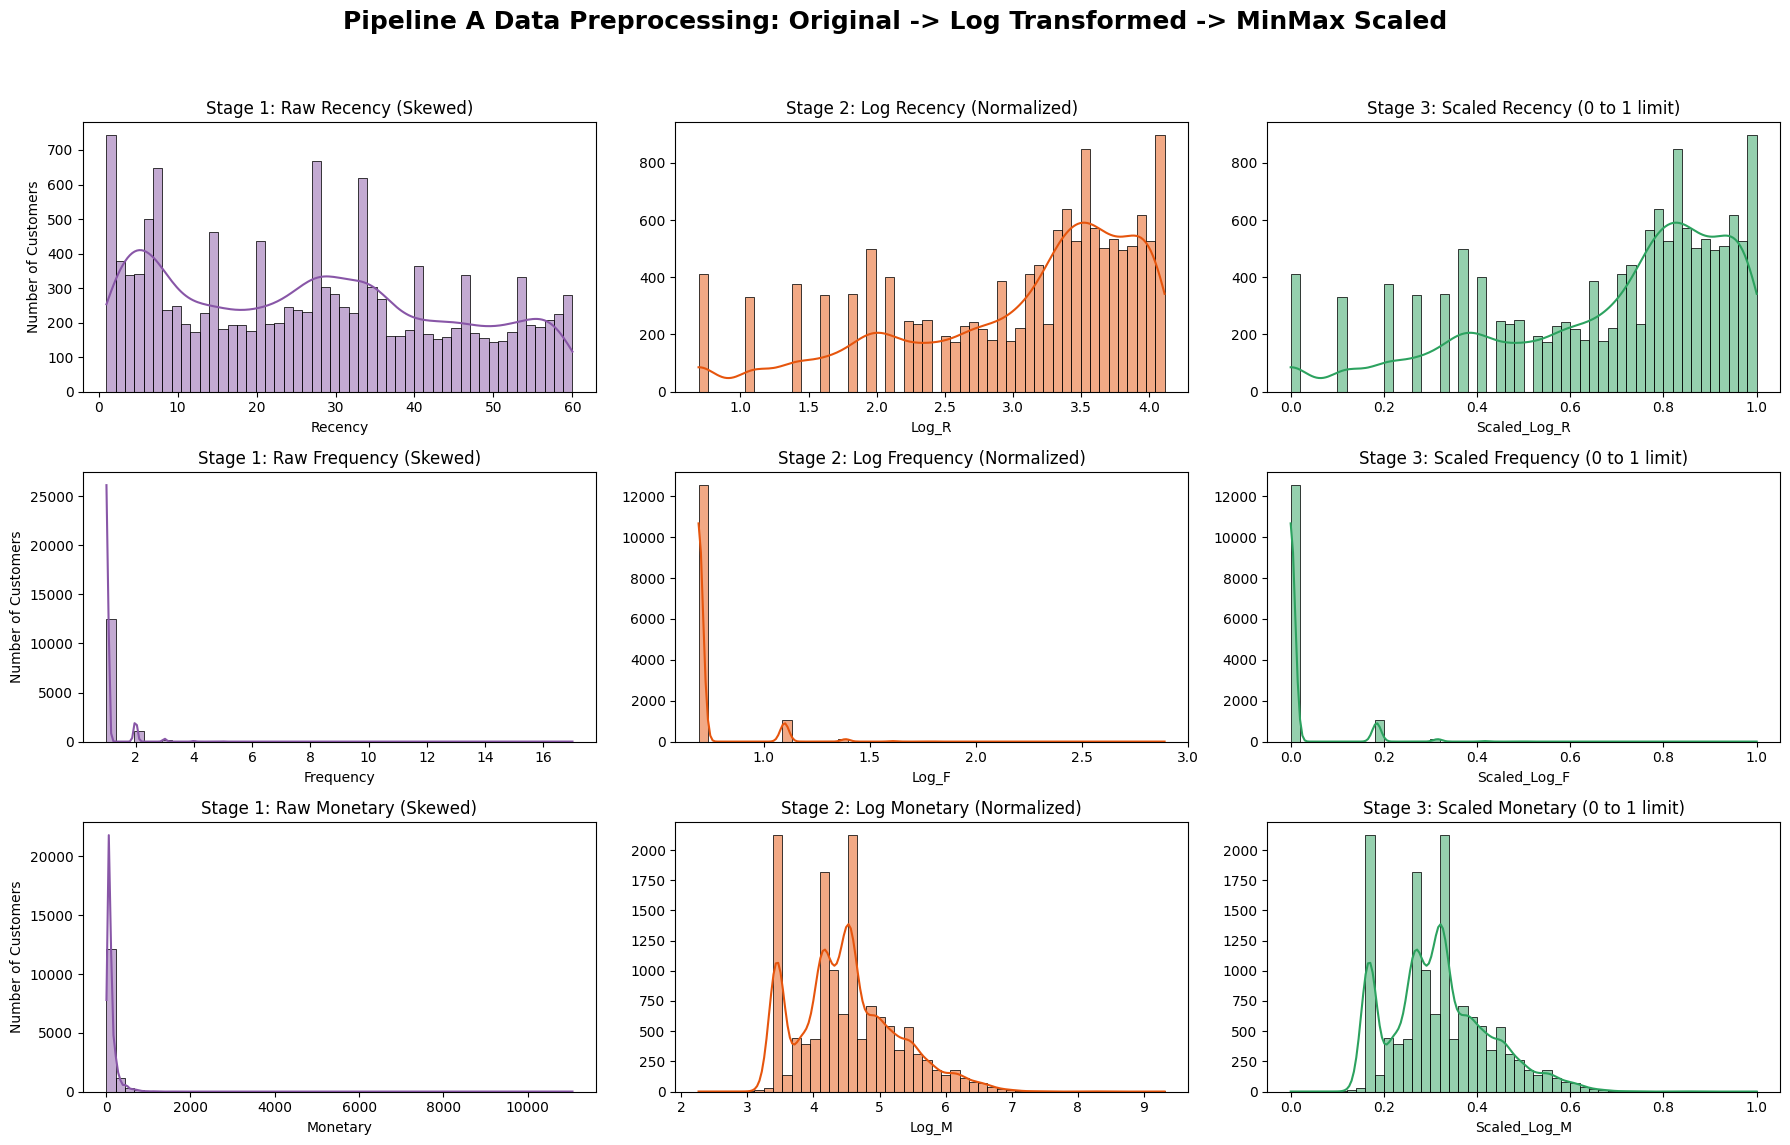

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALIZING THE FULL PREPROCESSING PIPELINE (PIPELINE A: COSMETICS) ---")

# We will use the Baseline Cycle (Cycle 0) for the plots
# Ensure rfm_cycles here is the one generated from your Cosmetic dataset!
baseline_rfm_a = rfm_cycles['Cycle_0']

# Set up a 3x3 grid of plots (3 rows for R, F, M and 3 columns for the stages)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Pipeline A Data Preprocessing: Original -> Log Transformed -> MinMax Scaled', fontsize=18, fontweight='bold')

# Feature lists to loop through
raw_features = ['Recency', 'Frequency', 'Monetary']
log_features = ['Log_R', 'Log_F', 'Log_M']
scaled_features = ['Scaled_Log_R', 'Scaled_Log_F', 'Scaled_Log_M']

# Stage Colors for Pipeline A (Purple, Orange, Teal)
colors = ['#8856a7', '#e6550d', '#2ca25f']

for i in range(3):
    # Column 1: BEFORE (Original Raw Data)
    sns.histplot(baseline_rfm_a[raw_features[i]], bins=50, ax=axes[i, 0], color=colors[0], kde=True)
    axes[i, 0].set_title(f'Stage 1: Raw {raw_features[i]} (Skewed)', fontsize=12)
    axes[i, 0].set_ylabel('Number of Customers')
    
    # Column 2: MIDDLE (Log Transformed)
    sns.histplot(baseline_rfm_a[log_features[i]], bins=50, ax=axes[i, 1], color=colors[1], kde=True)
    axes[i, 1].set_title(f'Stage 2: Log {raw_features[i]} (Normalized)', fontsize=12)
    axes[i, 1].set_ylabel('') # Hide y-label for middle to avoid clutter
    
    # Column 3: AFTER (MinMax Scaled)
    sns.histplot(baseline_rfm_a[scaled_features[i]], bins=50, ax=axes[i, 2], color=colors[2], kde=True)
    axes[i, 2].set_title(f'Stage 3: Scaled {raw_features[i]} (0 to 1 limit)', fontsize=12)
    axes[i, 2].set_ylabel('')

# Adjust layout so titles don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Creation of sql tables and database

In [ ]:
import sqlite3 
import random
from faker import Faker

# Database initialization
conn = sqlite3.connect('Cosmetic_Retail.db')
cursor = conn.cursor()

# Creation of Relational tables inside schema
# Customer Table
cursor.execute('''
  CREATE TABLE IF NOT EXISTS Customers (
    PERSON_ID INTEGER PRIMARY KEY,
    First_Name TEXT,
    Last_Name  TEXT, 
    Gender TEXT,
    Age INTEGER,
    ID_Number TEXT,
    Email TEXT,
    Phone_Number TEXT,
    Primary_Location TEXT,
    Climate_Zone TEXT, 
    Persona TEXT           
  )
''')

# Transactions Table 
cursor.execute('''
  CREATE TABLE IF NOT EXISTS Transactions (
      Trans_ID INTEGER PRIMARY KEY AUTOINCREMENT,
      PERSON_ID INTEGER,
      TRANSACTION_DATE TEXT,
      STORE_NO INTEGER,
      SKU_NUMBER INTEGER, 
      VALUE_AT_COST REAL,
      VALUE_AT_SELL REAL,
      FOREIGN KEY (PERSON_ID) REFERENCES Customers(PERSON_ID)
      )
''')

In [ ]:
# Create a table in SQL to store the RFM results for each cycle
cursor.execute('''
    CREATE TABLE IF NOT EXISTS RFM_History (
        PERSON_ID INTEGER,
        Time_Cycle INTEGER,
        Recency REAL,
        Frequency INTEGER,
        Monetary REAL,
        Recency_Bucket INTEGER,
        RF_Score REAL,
        RM_Score REAL,
        FM_Score REAL,
        PRIMARY KEY (PERSON_ID, Time_Cycle)
    )
''')

# LOOP THROUGH CYCLES
for cycle_id in sorted(df_nivea['Time_Cycle'].unique()):
    print(f"Processing Time Cycle {cycle_id}...")
    
    # Filter data for THIS cycle
    current_cycle_data = df_nivea[df_nivea['Time_Cycle'] == cycle_id]
    
    # The 'Snapshot Date' for RFM is the last day of this cycle
    cycle_snapshot = current_cycle_data['TRANSACTION_DATE'].max()
    
    # Run your Cascaded RFM function
    rfm_results = calculate_cascaded_rfm(current_cycle_data, cycle_snapshot)
    rfm_results['Time_Cycle'] = cycle_id
    rfm_results = rfm_results.reset_index()
    
    # Save results to SQL (This builds the history for your visualization interface)
    rfm_results.to_sql('RFM_History', conn, if_exists='append', index=False)

print(" All Time Cycles processed and stored in RFM_History.")

In [ ]:
cursor.execute('''
    CREATE TABLE IF NOT EXISTS RFM_History (
        PERSON_ID INTEGER,
        Time_Cycle INTEGER,
        Recency REAL,
        Frequency INTEGER,
        Monetary REAL,
        Recency_Bucket INTEGER,
        RF_Score REAL,
        RM_Score REAL,
        FM_Score REAL,
        Primary_Cluster INTEGER, -- <--- ADD THIS LINE
        PRIMARY KEY (PERSON_ID, Time_Cycle)
    )
''')

### USING FAKER LIBRARY TO SYNTHESIZE DATA VALUE FOR CUSTOMER TABLE

In [ ]:
# --- GEOGRAPHIC & CLIMATE MAPPING SETUP ---
# Mapping synthetic store numbers to SA cities and climate zones

# national cosmetic business but this data is only for its transactions in Cape Town
store_geo_map = {
    1: {'City': 'Johannesburg', 'Climate': 'Highveld (Dry)', 'Province': 'GP'},
    2: {'City': 'Cape Town', 'Climate': 'Mediterranean (Winter Rain)', 'Province': 'WC'},
    3: {'City': 'Durban', 'Climate': 'Subtropical (Humid)', 'Province': 'KZN'},
    4: {'City': 'Upington', 'Climate': 'Arid (Hot/Dry)', 'Province': 'NC'},
    5: {'City': 'Port Elizabeth', 'Climate': 'Oceanic (Temperate)', 'Province': 'EC'},
    # Add more stores as needed based on your synthetic dataset
}

def update_cycle_geography(conn, cycle_id):
    """Updates Primary_Location based on the 3-purchase rule for the current month."""
    query = f"SELECT PERSON_ID, STORE_NO, COUNT(*) as visit_count FROM Transactions WHERE Time_Cycle = {cycle_id} GROUP BY PERSON_ID, STORE_NO HAVING visit_count >= 3"
    loc_df = pd.read_sql_query(query, conn)
    
    for _, row in loc_df.iterrows():
        geo = store_geo_map.get(row['STORE_NO'], {'City': 'Unknown', 'Climate': 'Unknown'})
        cursor.execute("UPDATE Customers SET Primary_Location = ?, Climate_Zone = ? WHERE PERSON_ID = ?", 
                       (geo['City'], geo['Climate'], row['PERSON_ID']))
    conn.commit()

In [ ]:
#INITIALIZATION OF Fakeer  and 
fake = Faker(['en_ZA'])

def populate_customer_table(unique_ids):
  customer_records = [] # temporary location 

  for pid in unique_ids:
    # Determine Gender first to get matching names
    gender = random.choice(['M','F'])

    if gender == 'M':
      first_name = fake.first_name_male()
    else:
      first_name = fake.first_name_female()

    last_name = fake.last_name()

    # age and ID logic South african 13 digit     

    roll = np.random.random()
    age = np.random.randint(25,46) if roll < 0.65 else np.random.randint(18,75)

    birth_year = 2026 -age 

    yy = str(birth_year) [2:] 
    id_num = f"{yy}{random.randint(1,12):02d}{random.randint(1,28):02d}{random.randint(5000,9999)}08{random.randint(0,9)}"

    customer_records.append((int(pid),first_name,last_name,gender,age,id_num,fake.email(),fake.phone_number(),"unknown"))

cursor.executemany('INSERT OR IGNORE INTO Customers VALUES (?,?,?,?,?,?,?,?,?)', customer_records)
conn.commit()

# 4. INTELLIGENCE: The "3-Purchase Location Rule"
def update_geographic_intelligence():
    """
    Looks at transactions. If a customer has shopped at a specific STORE_NO 
    at least 3 times, we update their 'Primary_Location' in the Master Table.
    """
    # SQL query to find store loyalty
    query = '''
        SELECT PERSON_ID, STORE_NO, COUNT(*) as visit_count
        FROM Transactions
        GROUP BY PERSON_ID, STORE_NO
        HAVING visit_count >= 3
    '''
    loyalty_data = cursor.execute(query).fetchall()
    
    for pid, store, count in loyalty_data:
        # Map the Store ID to a name/area
        location_label = f"Area_Store_{store}"
        cursor.execute('UPDATE Customers SET Primary_Location = ? WHERE PERSON_ID = ?', (location_label, pid))
    
    conn.commit()
    print(f"Intelligence Update: {len(loyalty_data)} customers assigned to a primary location.")


# EXECUTE THE FUNCTIONS (Add this to the bottom of Cell 11)
all_unique_ids = df_nivea['PERSON_ID'].unique()

print("Synthesizing Customer Data...")
populate_customer_table(all_unique_ids)

print("Applying Geographic Intelligence...")
update_geographic_intelligence()

### Load transactions into the database

In [ ]:
# Ensuring to only push columns that match your SQL 'Transactions' table
transaction_cols = ['PERSON_ID', 'TRANSACTION_DATE', 'STORE_NO', 'SKU_NUMBER', 'VALUE_AT_COST', 'VALUE_AT_SELL']

df_nivea[transaction_cols].to_sql('Transactions', conn, if_exists='append', index=False)

print("Database loaded with cleaned and mapped transactions.")

## Feature Standardization & Initial K-Means

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. FETCH BASELINE DATA ---
# We pull Time Cycle 0 directly from our new SQL history table
query = "SELECT * FROM RFM_History WHERE Time_Cycle = 0"
baseline_rfm = pd.read_sql_query(query, conn)

# --- 2. FEATURE SELECTION ---
# We use the 'Cascaded' features you generated in Phase 1
features = ['Log_R', 'Log_F', 'Log_M', 'RF_Score', 'RM_Score', 'FM_Score']
X = baseline_rfm[features]

# --- 3. STANDARDIZATION (Critical for distance-based algorithms) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [ ]:
from scipy.spatial.distance import cdist
def calculate_xb_index(data, centroids, u, m=2.0):
    """
    Calculates the Xie-Beni (XB) Index for Fuzzy clustering quality.
    """
    n = data.shape[0]
    c = centroids.shape[0]
    
    # Calculate numerator: sum of squared fuzzy distances
    # Calculate denominator: minimum distance between centroids
    diff = np.expand_dims(data, axis=1) - np.expand_dims(centroids, axis=0)
    dist_sq = np.sum(diff**2, axis=2)
    numerator = np.sum((u**m).T * dist_sq)
    
    centroid_dist = cdist(centroids, centroids)**2
    # Fill diagonal with infinity so we don't pick 0 distance to itself
    np.fill_diagonal(centroid_dist, np.inf)
    min_centroid_dist = np.min(centroid_dist)
    
    xb_index = numerator / (n * min_centroid_dist)
    return xb_index

# You can now call this inside your CDFCM loop:
# xb = calculate_xb_index(X_cycle, active_centroids, u)
# print(f"Cycle {cycle_id} XB-Index: {xb:.4f}")

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. RUN K-MEANS BASELINE ---
# We use Cycle 0 as the "Static" starting point
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
baseline_rfm['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# Calculate Baseline Score for your report
base_sil = silhouette_score(X_scaled, baseline_rfm['Cluster_Label'])
print(f"Static K-Means Baseline (Cycle 0) Silhouette Score: {base_sil:.4f}")

# Extract Centroids to pass into the Dynamic Models
initial_centroids = kmeans.cluster_centers_

In [ ]:
import skfuzzy as fuzz
from scipy.spatial.distance import cdist

# --- CONFIGURATION ---
active_centroids = initial_centroids.copy() # Starts with Baseline centroids
DIST_THRESHOLD = 3.0  # Distance to trigger a NEW cluster (Creation)
MIN_WEIGHT = 10       # Minimum customers to keep a cluster (Deletion)
history_metrics = []

print("Starting Dynamic Updates (MDFCM vs CDFCM)...")

all_cycles = sorted(df_nivea['Time_Cycle'].unique())

for cycle_id in all_cycles:
    # 1. FETCH & SCALE DATA
    query = f"SELECT * FROM RFM_History WHERE Time_Cycle = {cycle_id}"
    cycle_df = pd.read_sql_query(query, conn)
    if len(cycle_df) < 10: continue
    X_cycle = scaler.transform(cycle_df[features])

    # 2. CDFCM LOGIC: CREATION & DELETION
    # Deletion: Remove centroids that no longer attract enough customers
    surviving_cntrs = [c for c in active_centroids if np.sum(cdist(X_cycle, [c]) < DIST_THRESHOLD) >= MIN_WEIGHT]
    
    # Creation: Add a new centroid if a group of outliers is found
    all_dists = cdist(X_cycle, surviving_cntrs)
    outliers = X_cycle[np.min(all_dists, axis=1) > DIST_THRESHOLD]
    if len(outliers) >= MIN_WEIGHT:
        surviving_cntrs.append(np.mean(outliers, axis=0))
        print(f"Cycle {cycle_id}: New Segment Detected!")

    active_centroids = np.array(surviving_cntrs)

    # 3. EXECUTE FUZZY UPDATES
    # We run FCM using the dynamically updated 'active_centroids'
    cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
        X_cycle.T, c=len(active_centroids), m=2.0, error=0.005, maxiter=1000, 
        init=active_centroids if cycle_id > 0 else None
    )
    update_cycle_geography(conn, cycle_id)

    # Fetch transactions using SKU_NUMBER instead
    query = f'''
        SELECT t.PERSON_ID, t.SKU_NUMBER, h.Primary_Cluster, c.Age, c.Gender
        FROM Transactions t
        JOIN RFM_History h ON t.PERSON_ID = h.PERSON_ID AND h.Time_Cycle = {cycle_id}
        JOIN Customers c ON t.PERSON_ID = c.PERSON_ID
        WHERE t.Time_Cycle = {cycle_id}
    '''
    persona_data = pd.read_sql_query(query, conn)

    # --- SYNTHETIC SKU MAPPING ---
    # Assigns random Nivea categories to your SKUs so the Persona logic works
    synthetic_categories = ['nivea men shave', 'q10 anti-age', 'perfect & radiant', 'sun care 400ml', 'lip care soft', 'daily body lotion']
    
    def map_sku_to_category(sku):
        # Deterministically picks a category based on the SKU number
        return synthetic_categories[sku % len(synthetic_categories)]
        
    persona_data['Product_Category'] = persona_data['SKU_NUMBER'].apply(map_sku_to_category)
    

    def assign_nivea_persona(row):
        # Convert category to lowercase for easier string matching
        category = str(row['Product_Category']).lower()
        age = row['Age']
        gender = row['Gender']
        cluster = row['Primary_Cluster'] 
        
        # NOTE: Assuming Cluster 0 is your "High Value/Loyal" cluster based on previous setup.
        # Adjust the cluster number if your High Value cluster is 1, 2, or 3.

        # 1. The "Active Groomer" (Nivea Men focus)
        if gender == 'Male' and ('men' in category or 'shave' in category or 'sport' in category):
            return "Active Groomer"
            
        # 2. The "Skin Health Purist" (Premium, Anti-Aging focus - e.g., Q10, Luminous630)
        elif 'q10' in category or 'anti-age' in category or 'luminous' in category or (age >= 45 and cluster == 0):
            return "Skin Health Purist"
            
        # 3. The "Radiance Seeker" (Highly relevant in SA - Perfect & Radiant, Even Tone)
        elif 'radiant' in category or 'even tone' in category or 'face wash' in category:
            return "Radiance Seeker"
            
        # 4. The "Family Caretaker" (Bulk buyers, Sun care, Kids products)
        elif 'sun' in category or 'kids' in category or (30 <= age <= 45 and '400ml' in category and cluster == 0):
            return "Family Caretaker"
            
        # 5. The "Youthful Trendsetter" (Gen Z, Lip care, Soft creams, active buyers)
        elif age <= 25 and ('lip' in category or 'soft' in category or 'color' in category):
            return "Youthful Trendsetter"
            
        # 6. The Default / Baseline (Standard Deodorants, basic body lotions)
        else:
            if gender == 'Male':
                return "Grooming Minimalist"
            else:
                return "Daily Essentialist"

    persona_data['Persona'] = persona_data.apply(assign_nivea_persona, axis=1)


    # 4. STORE RESULTS & LOG METRICS
    cycle_df['Primary_Cluster'] = np.argmax(u, axis=1)
    active_centroids = cntr # Migration for next cycle
    # Save these cluster labels back to the SQL database
    for idx, row in cycle_df.iterrows():
        cursor.execute('''
            UPDATE RFM_History 
            SET Primary_Cluster = ? 
            WHERE PERSON_ID = ? AND Time_Cycle = ?
        ''', (int(row['Primary_Cluster']), int(row['PERSON_ID']), cycle_id))
    conn.commit()

    # Save Psychographic Personas back to the Customers table
    # We drop duplicates so we only update each customer once per cycle
    for _, row in persona_data[['PERSON_ID', 'Persona']].drop_duplicates().iterrows():
        cursor.execute('''
            UPDATE Customers 
            SET Persona = ? 
            WHERE PERSON_ID = ?
        ''', (row['Persona'], row['PERSON_ID']))
    conn.commit()
    
    # Calculate XB-Index (Lower is better)
    xb = calculate_xb_index(X_cycle, cntr, u)
    history_metrics.append({
        'Cycle': cycle_id, 'FPC': fpc, 'XB': xb, 
        'Clusters': len(active_centroids), 'Sil': silhouette_score(X_cycle, cycle_df['Primary_Cluster'])
    })

df_metrics = pd.DataFrame(history_metrics)
print("\nAll cycles processed. Model evolved dynamically.")

### plots

In [ ]:
import plotly.express as px

# We will visualize the CDFCM results from the latest cycle
# Assuming cycle_data is the dataframe from your last loop
fig = px.scatter_3d(cycle_df, 
                    x='RF_Score', 
                    y='RM_Score', 
                    z='FM_Score',
                    color='Primary_Cluster',
                    title="Dynamic Customer Segments (CDFCM)",
                    labels={'Primary_Cluster': 'Segment'},
                    hover_data=['PERSON_ID', 'Recency', 'Monetary'])

fig.update_layout(scene = dict(
                    xaxis_title='Loyalty-Frequency (RF)',
                    yaxis_title='Loyalty-Value (RM)',
                    zaxis_title='Purchase-Power (FM)'))

fig.show()

# Plotting Evaluation Metrics to prove model stability
fig_eval = px.line(df_metrics, x='Cycle', y=['Sil', 'FPC'], 
                  title="Model Quality (Silhouette & FPC) Over Time",
                  labels={'value': 'Score', 'variable': 'Metric'})
fig_eval.show()
# To save for your website:
# fig.write_html("cluster_dashboard.html")

In [ ]:
# Create a summary of cluster counts per cycle
migration_data = pd.read_sql_query("""
    SELECT Time_Cycle, Primary_Cluster, COUNT(PERSON_ID) as Customer_Count 
    FROM RFM_History 
    GROUP BY Time_Cycle, Primary_Cluster
""", conn)

fig_migration = px.area(migration_data, 
                        x="Time_Cycle", 
                        y="Customer_Count", 
                        color="Primary_Cluster",
                        line_group="Primary_Cluster",
                        title="Customer Segment Migration Over Time")

fig_migration.show()

Adding the XB-Index (The Final Metric)